In [1]:
# Paso 2: Importar librerías
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from datasets import Dataset
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import numpy as np
import torch

# Paso 3: Cargar y preparar el dataset
df = pd.read_csv("mails_dataset.csv")  # Cambia la ruta si hace falta

# Nos centramos solo en las columnas necesarias
df = df[["text", "sentiment"]].dropna()

# Codificar etiquetas de sentimiento
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])

# Guardar mappings para uso posterior
label2id = {label: i for i, label in enumerate(label_encoder.classes_)}
id2label = {i: label for label, i in label2id.items()}

# Paso 4: Crear Dataset Hugging Face
dataset = Dataset.from_pandas(df[["text", "label"]].rename(columns={"text": "text", "label": "label"}))

# Paso 5: Tokenización
model_name = "pysentimiento/robertuito-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(batch["text"], padding=True, truncation=True)

dataset = dataset.map(tokenize, batched=True)

# Dividir en entrenamiento y validación (80/20)
dataset = dataset.train_test_split(test_size=0.2)

# Paso 6: Cargar modelo preentrenado para clasificación con las etiquetas definidas
num_labels = len(label2id)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

# Paso 7: Configurar argumentos de entrenamiento
training_args = TrainingArguments(
    output_dir="./modelo_sentiment",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=6,
    weight_decay=0.01,
    logging_dir="./logs_sentiment",
    logging_steps=10,
    load_best_model_at_end=True,
    metric_for_best_model="f1"
)

# Paso 8: Función de evaluación
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = np.argmax(pred.predictions, axis=1)
    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")
    return {"accuracy": acc, "f1": f1}

# Paso 9: Crear Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

# Paso 10: Entrenar modelo
trainer.train()

# Paso 11: Guardar modelo y tokenizer
trainer.save_model("./modelo_sentiment")
tokenizer.save_pretrained("./modelo_sentiment")


c:\Users\Usuario\Desktop\MailClassifier\.venv\lib\site-packages\huggingface_hub\file_download.py:943: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Map:   0%|          | 0/124 [00:00<?, ? examples/s]

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at pysentimiento/robertuito-base-uncased and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  0%|          | 0/78 [00:00<?, ?it/s]

c:\Users\Usuario\Desktop\MailClassifier\.venv\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


...

  0%|          | 0/4 [00:00<?, ?it/s]

{'eval_loss': 0.6389434337615967, 'eval_accuracy': 0.92, 'eval_f1': 0.9216666666666665, 'eval_runtime': 0.6198, 'eval_samples_per_second': 40.334, 'eval_steps_per_second': 6.454, 'epoch': 2.0}


c:\Users\Usuario\Desktop\MailClassifier\.venv\lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 0.617, 'grad_norm': 4.727113723754883, 'learning_rate': 1.230769230769231e-05, 'epoch': 2.31}


KeyboardInterrupt: 

Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


=== Reporte clasificación Sentiment ===
              precision    recall  f1-score   support

    negativo       0.98      0.98      0.98        53
      neutro       0.97      0.97      0.97        93
    positivo       0.96      0.96      0.96        77

    accuracy                           0.97       223
   macro avg       0.97      0.97      0.97       223
weighted avg       0.97      0.97      0.97       223



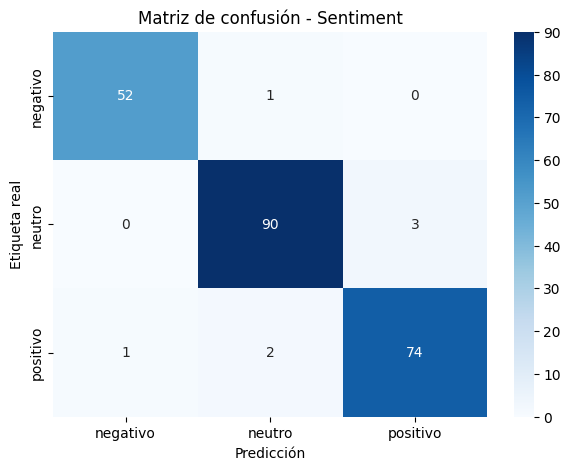

In [4]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import pandas as pd
import numpy as np
import torch

# Cargar dataset y preparar etiquetas igual que en entrenamiento
df = pd.read_csv("dataset_limpio.csv")
df = df[["text", "sentiment"]].dropna()

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["sentiment"])

labels = label_encoder.classes_

# Cargar modelo y tokenizer
tokenizer = AutoTokenizer.from_pretrained("./modelo_sentiment")
model = AutoModelForSequenceClassification.from_pretrained("./modelo_sentiment")

# Tokenizar textos (usa batches si tienes muchos datos)
tokens = tokenizer(df["text"].tolist(), padding=True, truncation=True, return_tensors="pt")

with torch.no_grad():
    outputs = model(**tokens)
preds = torch.argmax(outputs.logits, axis=1).numpy()

# Mostrar reporte detallado
print("=== Reporte clasificación Sentiment ===")
print(classification_report(df["label"], preds, target_names=labels))

# Matriz de confusión
cm = confusion_matrix(df["label"], preds)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - Sentiment")
plt.show()


In [2]:
from transformers import pipeline

# Cargar el modelo y tokenizer ya entrenados para SENTIMENT
clf_sentiment = pipeline("text-classification", model="./modelo_sentiment", tokenizer="./modelo_sentiment")

# Lista de ejemplos: (texto, sentimiento_esperado)
ejemplos_sentiment = [
    ("Mi pedido no ha llegado y ya pasaron 10 días", "negativo"),
    ("El repartidor fue descortés", "negativo"),
    ("¿Pueden confirmarme si tienen stock del producto?", "neutro"),
    ("Gracias por la atención, todo perfecto", "positivo"),
    ("Recibí una caja vacía sin el producto dentro", "negativo"),
    ("Quisiera modificar la dirección de entrega", "neutro"),
    ("Nos gustaría evaluar una posible alianza comercial", "neutro"),
    ("El servicio fue correcto, pero la web es un poco confusa", "neutro"),
    ("Solicito el alta inmediata del servicio para un cliente", "neutro"),
    ("No me llegó el correo de activación, pero puedo esperar", "negativo"),
]

# Imprimir resultados
print(f"{'Texto':<60} | {'Esperado':<9} | {'Predicción':<10} | {'Score'}")
print("-" * 100)

for texto, esperado in ejemplos_sentiment:
    pred = clf_sentiment(texto)[0]
    print(f"{texto[:57]:<60} | {esperado:<10} | {pred['label']:<10} | {pred['score']:.4f}")


Texto                                                        | Esperado  | Predicción | Score
----------------------------------------------------------------------------------------------------
Mi pedido no ha llegado y ya pasaron 10 días                 | negativo   | negativo   | 0.9187
El repartidor fue descortés                                  | negativo   | negativo   | 0.8787
¿Pueden confirmarme si tienen stock del producto?            | neutro     | neutro     | 0.9664
Gracias por la atención, todo perfecto                       | positivo   | positivo   | 0.9581
Recibí una caja vacía sin el producto dentro                 | negativo   | negativo   | 0.8842
Quisiera modificar la dirección de entrega                   | neutro     | neutro     | 0.9060
Nos gustaría evaluar una posible alianza comercial           | neutro     | neutro     | 0.7516
El servicio fue correcto, pero la web es un poco confusa     | neutro     | positivo   | 0.4987
Solicito el alta inmediata del servic